# 10 Live Demo for current 2025-26 NBA Playoffs


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))
from src import bracket, series, plot_style
plot_style.apply()

DATA = Path("..") / "data" / "processed"
df = pd.read_parquet(DATA / "games_with_advanced_features.parquet")

SEASON = 2025
season_games = df[df.season == SEASON]
playoffs = season_games[season_games.gameType == "Playoffs"]
print(f"Season {SEASON}: {len(season_games):,} games, of which {len(playoffs)} playoff games")
print(f"Last game in the dataset: {season_games.gameDate.max().date()}")

Season 2025: 1,260 games, of which 30 playoff games
Last game in the dataset: 2026-04-26


## Current ELO ranking 

Pre-playoff ELO for each team (Top 20)

In [2]:
names = pd.concat([
    df[['gameDate', 'hometeamId', 'hometeamName']].rename(columns={'hometeamId': 't', 'hometeamName': 'n'}),
    df[['gameDate', 'awayteamId', 'awayteamName']].rename(columns={'awayteamId': 't', 'awayteamName': 'n'}),
]).sort_values('gameDate').drop_duplicates('t', keep='last').set_index('t')['n']



home_v = playoffs[['gameDate', 'hometeamId', 'home_elo_pre']].rename(columns={'hometeamId': 't', 'home_elo_pre': 'e'})
away_v = playoffs[['gameDate', 'awayteamId', 'away_elo_pre']].rename(columns={'awayteamId': 't', 'away_elo_pre': 'e'})
preplay = pd.concat([home_v, away_v]).sort_values(['t', 'gameDate']).groupby('t').first()['e']

elo_table = preplay.rename(index=names).sort_values(ascending=False).head(20)
elo_table.round(0).to_frame('Pre-Playoff ELO')

,Pre-Playoff ELO
t,
Thunder,1758.0
Spurs,1707.0
Celtics,1685.0
Pistons,1662.0
Nuggets,1659.0
Cavaliers,1632.0
Knicks,1630.0
Lakers,1625.0
Rockets,1598.0


## Current R1 matchups + live results

In [3]:
playoffs = playoffs.copy()
playoffs["team_pair"] = playoffs.apply(lambda r: tuple(sorted([r.hometeamId, r.awayteamId])), axis=1)

round1 = []
round1_state = []   # same data but with IDs + raw wins, for the simulator below

for pair, grp in playoffs.groupby("team_pair"):
    higher = grp.hometeamId.value_counts().idxmax()
    lower = [t for t in pair if t != higher][0]
    wins_h = ((grp.hometeamId == higher) & (grp.home_win == 1)).sum() + \
             ((grp.awayteamId == higher) & (grp.home_win == 0)).sum()
    
    wins_l = len(grp) - wins_h
    
    round1.append({
        "higher": names.get(higher, str(higher)),
        "lower":  names.get(lower, str(lower)),
        "higher_elo": round(preplay.get(higher, 1500)),
        "lower_elo":  round(preplay.get(lower, 1500)),
        "series_score": f"{max(wins_h, wins_l)}-{min(wins_h, wins_l)}",
        "leader": names.get(higher, "?") if wins_h > wins_l else (names.get(lower, "?") if wins_l > wins_h else "tied"),
        "games_played": len(grp),})
    round1_state.append((higher, lower, int(wins_h), int(wins_l)))

# sort both lists the same way (by higher ELO descending) so they stay aligned
order = sorted(range(len(round1)), key=lambda i: -round1[i]["higher_elo"])
round1 = [round1[i] for i in order]
round1_state = [round1_state[i] for i in order]

pd.DataFrame(round1)

,higher,lower,higher_elo,lower_elo,series_score,leader,games_played
0,Thunder,Suns,1758,1520,3-0,Thunder,3
1,Spurs,Trail Blazers,1707,1521,3-1,Spurs,4
2,Celtics,76ers,1685,1513,3-1,Celtics,4
3,Pistons,Magic,1662,1540,2-1,Magic,3
4,Nuggets,Timberwolves,1659,1587,3-1,Timberwolves,4
5,Cavaliers,Raptors,1632,1516,2-2,tied,4
6,Knicks,Hawks,1630,1563,2-2,tied,4
7,Lakers,Rockets,1625,1598,3-1,Lakers,4


## Championship probabilities — using the REAL R1 matchups + current series state

The old version of this cell synthetically seeded the top-16 ELO teams into a fake bracket. That was wrong — the actual R1 pairings live in the games data above (Knicks vs Hawks, Cavs vs Raptors, etc.), and some of them already have games played.

What I now do:
1. Take the 8 real R1 matchups from `round1_state` above
2. Continue each series from its current score (so a 3-0 Thunder gets ~95% to advance, a 2-2 tied series is closer to a coinflip)
3. For R2+ I pair survivors by ELO rank order — I dont have the real bracket structure (East 1v8 vs 4v5 etc.) baked into the data, so this is an approximation. Doesnt change the headline picks much.


In [4]:
from src import elo as elo_mod
HOME_PATTERN = series.NBA_HOME_PATTERN

def simulate_series_from_state(higher_elo, lower_elo, wins_h, wins_l, rng):
    """Continue a Best-of-7 from a partial score. Returns True if the higher seed advances."""
    # already decided?
    if wins_h >= 4: return True
    if wins_l >= 4: return False
    game_idx = wins_h + wins_l   # next game number (0-indexed)
    wh, wl = wins_h, wins_l
    for is_high_home in HOME_PATTERN[game_idx:]:
        p = elo_mod.win_prob(higher_elo, lower_elo, is_home=bool(is_high_home))
        if rng.random() < p: wh += 1
        else:                wl += 1
        if wh == 4: return True
        if wl == 4: return False
    return wh > wl

# build the ELO dict for every team that's actually in R1
elos = {t: float(preplay.get(t, 1500)) for pair in round1_state for t in pair[:2]}
team_ids = list(elos.keys())

rng = np.random.default_rng(42)
champ_counts = {t: 0 for t in team_ids}
N_SIM = 10000

for _ in range(N_SIM):
    # R1: continue each real matchup from its current state
    r1_winners = []
    for higher, lower, wh, wl in round1_state:
        higher_wins = simulate_series_from_state(elos[higher], elos[lower], wh, wl, rng)
        r1_winners.append(higher if higher_wins else lower)

    # R2-R4: re-seed by ELO and pair top vs bottom of the remaining field.
    # Not a true NBA bracket but it's the cleanest assumption without conference data.
    bracket_round = r1_winners
    while len(bracket_round) > 1:
        ranked = sorted(bracket_round, key=lambda t: -elos[t])
        next_round = []
        # pair best-vs-worst, 2nd-vs-2nd-worst, etc.
        for i in range(len(ranked) // 2):
            a, b = ranked[i], ranked[-(i + 1)]
            higher, lower = (a, b) if elos[a] >= elos[b] else (b, a)
            higher_wins = series.simulate_b07_elo(elos[higher], elos[lower], rng=rng)
            next_round.append(higher if higher_wins else lower)
        bracket_round = next_round

    champ_counts[bracket_round[0]] += 1

probs = pd.Series({names.get(t, str(t)): c / N_SIM for t, c in champ_counts.items()}).sort_values(ascending=False)

print("Top-5 championship picks for 2025-26 (R1 state from real games):")
print(probs.head(5).apply(lambda v: f"{v:.1%}"))

Top-5 championship picks for 2025-26 (R1 state from real games):
Thunder      58.5%
Spurs        21.6%
Celtics      11.2%
Pistons       3.2%
Cavaliers     1.7%
dtype: object


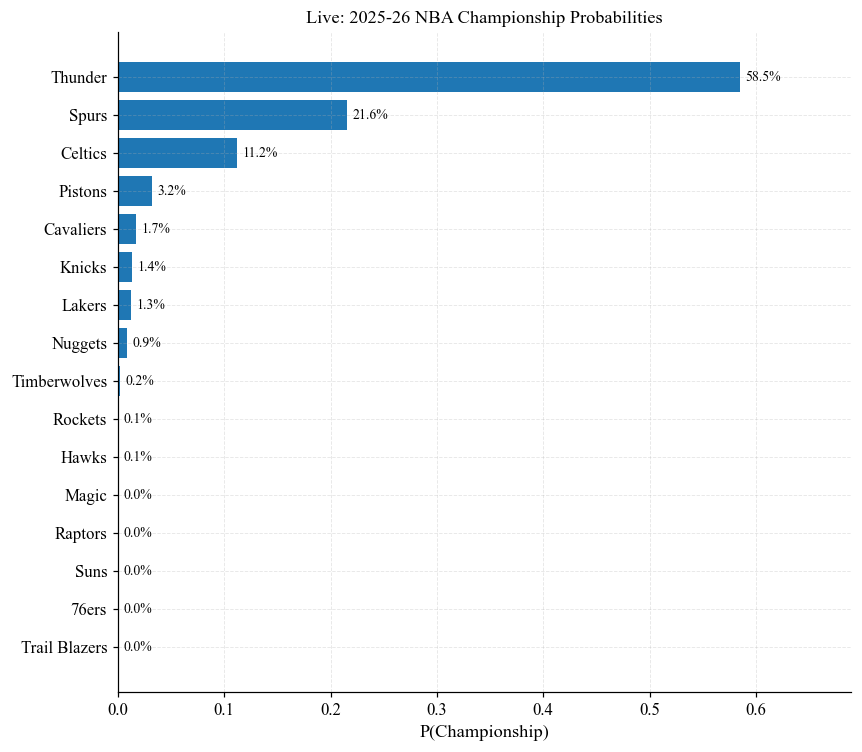

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
view = probs.sort_values()

ax.barh(view.index, view.values, color=plot_style.COLORS["primary"])
ax.set_xlabel("P(Championship)")
ax.set_title(f"Live: 2025-26 NBA Championship Probabilities")

for i, v in enumerate(view.values):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)
ax.set_xlim(0, max(view.values) * 1.18)
plt.tight_layout()
plt.show()